# Introduction to Machine Learning

This week, we'll begin working with machine learning. First, we are going to talk about the objective of machine learning and then discuss the involved terminology. To this end, we'll utilize one of the simplest algorithms in the field, named *kNN* to serve as an example.

<image width="500" height="300" src="https://i.imgur.com/vn9NUkD.png"></image>

In addition, we'll also be talking about [sklearn](https://scikit-learn.org/stable/), a Python library specialized for machine learning.

## What is Machine Learning?

> **A set of methods that can automatically detect patterns in data,  and then use the uncovered patterns to predict future data, or to perform other kinds of decision making under uncertainty**. 
*Murphy K.P. Machine Learning A Probabilistic Perspective.*

Typically, our goal is to use the data to develop models that we can use to predict various outcomes for new data, such as:

- Predicting whether an email message is spam or not

- Predicting whether a credit card transaction is fraudulent

- Predicting which advertisement a shopper is most likely to click on



## Key Terms

- **Instance (Observation)**: The thing about which you want to make a prediction.

- **Example**: An instance (with its features) and a label.

- **Label**: A label is the thing we're predicting.

- **Feature**: A feature is an input variable. A simple machine learning project might use a single feature, while a more sophisticated machine learning project could use millions of features. Features are the inputs to be fed to the models.

- **Model**: A statistical representation of a prediction task. You train a model on examples then use the model to make predictions.

Obtained from [Google Guidelines](https://developers.google.com/machine-learning/guides/rules-of-ml/)

## Supervised vs Unsupervised

<image width="500" height="300" src="https://storage.googleapis.com/groundai-web-prod/media/users/user_215981/project_350445/images/Supervised_Learning.png"></image>

Within the field of machine learning, there are two main types of tasks: **supervised**, and **unsupervised**. The main difference between the two types is that supervised learning is performed by utilizing the ground truth, or in other words, we have prior knowledge of what the output values for our samples should be. Therefore, **the goal of supervised learning is to learn a function, given a set of observations and associated outputs, that best approximates the relationship, mapping between them**.

Unsupervised learning, on the other hand, does not have labeled data, so **its goal is to infer the natural structure present within a set of data points**.

## Supervised Learning

Supervised learning is typically done in the context of classification, when we want to map input to output labels, or regression, when we want to map inputs to a continuous output.

<img height="400" width="700" src="https://miro.medium.com/max/3200/1*ASYpFfDh7XnreU-ygqXonw.png"></img>

**Classification Models**

What classification models aim to achieve can be summarized above. It is the task of approximating a mapping function (f) from input variables (X) to discrete output variables (y). The output variables are often called labels or categories. The mapping function predicts the class or category for a given observation.

**Regression Models**

It is the task of approximating a mapping function (f) from input variables (X) to a **continuous output variable (y).** A continuous output variable is a real-value, such as an integer or floating point value. These are often quantities, such as amounts and sizes.

## k-Nearest Neighbours

kNN is a simple, yet a powerful machine learning algorithm. The main idea behind kNN is to check the surroundings of the given instance. It's a supervised algorithm and can be used in both classification and regression. It simply calculates the distance of a new data point to all other training data points. It then selects the K-nearest data points, where K can be any integer. Finally, it assigns the data point to the class to which the majority of the K data points belong.

Here, K is a **hyperparameter**. A hyperparameter is a parameter of your model that is set before the training.

![](http://res.cloudinary.com/dyd911kmh/image/upload/f_auto,q_auto:best/v1531424125/KNN_final1_ibdm8a.png)



**KNN Classifier Pseudocode**

- Set neighbourhood size `K`.
- Calculate the distances between the test data and each instance of the training data.
- Sort the calculated distances in ascending order with respect to the distances.
- Get top `K` from the sorted array, which will constitute the nearest neighbours.
- Find the most frequent label among the nearest neighbours.
- Assign that label to test data.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from os.path import join

%matplotlib inline

In [ ]:
def create_2D_sample(mean, std, n, label):
  """
  given a set of sample parameters
  returns a 2D sample
  """
  # create data points
  xvals = np.random.normal(loc=mean, scale=std, size=n).reshape(-1,1)
  yvals = np.random.normal(loc=mean, scale=std, size=n).reshape(-1,1)

  # class labels
  labels = np.repeat(label, n).reshape(-1,1)

  # merge observations and assigned labels
  sample = np.hstack([xvals, yvals, labels])

  return sample

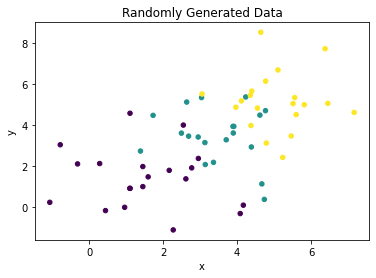

In [ ]:
# number of observations
n = 20
# number of classes
n_classes = 3
# fix the random seed
np.random.seed(42)

# sample parameters
means = [1.8, 3.5, 5.1]
stds = [1.5, 1.2, 1.4]

d = []
for label in range(n_classes):
  sample = create_2D_sample(means[label], stds[label], n, label)
  d.append(sample)

data = np.vstack(d)

plt.scatter(data[:,0], data[:,1], c=data[:,2], s=20)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Randomly Generated Data")
plt.show()

### Exercise: Nearest Neighbours

Instructions

- Once you are assigned to a breakout room, discuss among yourselves to decide who will be sharing the screen to collectively develop a solution. Actively participate in the group discussion.
- For your questions, you may use the `request help` button on the zoom menu.

In this exercise, you are going to find the `k nearest neighbours` for a new data point and then assign the most frequent class label to that data point.

In the cell above, we created toy data and stored it in a variable name `data`, which is a 2D numpy array where each row contains three values:  

- x, y and the label for that instance.

```py
# a 2D numpy array
# x, y, label
>>> data
array([[ 2.54507123,  3.99847315,  0.        ],
       [ 1.59260355,  1.46133555,  0.        ],
       [ 2.77153281,  1.90129231,  0.        ],
       ...
```

In the visualizations, we utilize colors to encode class labels.


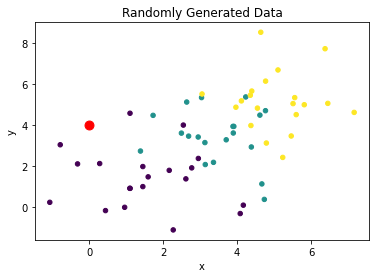

In [ ]:
# new data point
d = np.array([[0,4]])

# let's visualize its location on the chart
plt.scatter(data[:,0], data[:,1], c=data[:,2], s=20)
plt.scatter(d[:,0], d[:,1], s=80, c="red")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Randomly Generated Data")
plt.show()

In the figure above, the red dot, stored in variable `d`, represents the new data point for which we do not know the class label. Your task is to predict a class label with respect to its nearest k neighbours, where `k` is the neighbourhood size.

To compute the distances between the new data point `d` and the instances in `data`, you can use the euclidean distance from scipy https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.euclidean.html. 

```py
>>> from scipy.spatial import distance
>>> distance.euclidean([1, 0], [0, 1])
1.4142135623730951
```

---

Steps:

- Set `k` to a value of your choice.

- Calculate the distances between the new data point `d` and the instances in the data.

  - You may use the `euclidean` distance function from scipy as described above.  

- Store the distances in an iterable object, alongside the labels.

- Sort that iterable object with respect to the resulting distances.

- Obtain the first k instances that will constitute the nearest k neighbours.

- Return the most frequent label in that neighbourhood as the prediction for the new data point.

---

Once compute your prediction for the new data point, create a visualization as we did above and color the new data point based on its predicted label.

The result should look like the figure below.

![](https://i.ibb.co/X5vxFkr/cc.png)

In [ ]:
# your code

## Sklearn

Now, let's apply kNN with different *k* values. To this end, we are going to utilize a new library named *sklearn* to employ various machine learning models. It's essential for you to understand and effectiely utilize sklearn and its functionalities. Please check the tutorials below and practice on your own.

- https://scikit-learn.org/stable/tutorial/index.html
- https://scikit-learn.org/stable/tutorial/basic/tutorial.html

**Sklearn Structure**

![](https://i.imgur.com/p7X0i2E.png)

**Model Life Cycle**

![](https://i.imgur.com/HPKXgs2.png)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# set the hyperparameter k
k=3
# generate the model
model = KNeighborsClassifier(k, metric="euclidean")

# extract features and labels from the data
features = data[:, :2]
labels = data[:, 2]

# fit data
model.fit(features, labels)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='euclidean',
                     metric_params=None, n_jobs=None, n_neighbors=3, p=2,
                     weights='uniform')

Now, we have a model. Let's repeat the same exercise with sklearn this time.

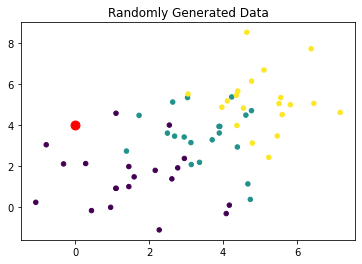

In [ ]:
# new data point
d = np.array([[0,4]])

# let's visualize its location on the chart
plt.scatter(data[:,0], data[:,1], c=data[:,2], s=20)
plt.scatter(d[:,0], d[:,1], s=80, c="red")
plt.title("Randomly Generated Data")
plt.show()

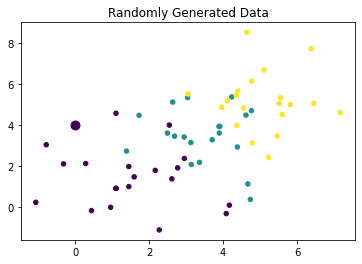

In [ ]:
# now we can make the prediction
# pred is just another numpy array
# that stores the predicted labels
pred = model.predict(d)

# now let's also visualize the assigned color
plt.scatter(data[:,0], data[:,1], c=data[:,2], s=20)
plt.scatter(d[:,0], d[:,1], s=80, c=pred)
plt.title("Randomly Generated Data")
plt.show()

The model finds the closest two data points and assigns the label accordingly.

As a result, the newly generated data point is assigned as label 0, color blue.


## Classification Boundaries

In addition, we can also visualize the boundaris for classifications.

In [ ]:
from matplotlib.colors import ListedColormap
from ipywidgets import interact

def visualize_knn(k):
  # generate the model
  model = KNeighborsClassifier(k)

  # extract features and labels from the data
  features = data[:, :2]
  labels = data[:, 2]

  # fit data
  model.fit(features, labels)

  step = 0.1

  cmap_light = ListedColormap(['orange', 'cyan', 'cornflowerblue'])
  cmap_bold = ListedColormap(['darkorange', 'c', 'darkblue'])

  x_min = data[:, 0].min() - 1
  x_max = data[:, 0].max() + 1
  y_min = data[:, 1].min() - 1
  y_max = data[:, 1].max() + 1

  xx, yy = np.meshgrid(np.arange(x_min, x_max, step), np.arange(y_min, y_max, step))
  labels = model.predict(np.hstack([xx.reshape(-1,1), yy.reshape(-1,1)]))

  # Put the result into a color plot
  labels = labels.reshape(xx.shape)
  plt.figure()
  plt.pcolormesh(xx, yy, labels, cmap=cmap_light)
  plt.scatter(data[:, 0], data[:, 1], c=data[:,2], cmap=cmap_bold, edgecolor='k', s=20)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())
  plt.show()

interact(visualize_knn, k=(1,10))

interactive(children=(IntSlider(value=5, description='k', max=10, min=1), Output()), _dom_classes=('widget-int…

<function __main__.visualize_knn>

## Model Evaluation: Partitioning the Dataset

In a general machine learning pipeline, most of the models possess hyperparameters that shoudl be set before the training process begins. Depending on the value of the hyperparameter, the performance of your model would alter. So, how are we going to determine the value of hyperparameters?

#### Train, Validation & Test Dataset

Utilizing the entire dataset for both training and testing is a very harmful practice. Instead, partition your dataset into two folds, namely *training* and *testing*. With training dataset, you fit (train) your model and then test your model with the reserved test data which is never exposed to the model beforehand. So that your model's ability to predict unseen data will be tested. We are going to be talking about this issue in the upcoming weeks in detail.

<img height="250" width="500" src="https://i.stack.imgur.com/pXAfX.png"/>

In order to determine the optimal set of hyperparameters, you should further partition data. In this setting, in addition to the training and testing folds, you'll also need a *validation* set to *fine-tune the hyperparameters* in your model.

---

In summary:

**Train Dataset:** A sample of the actual data to be used for training your model. Your model will be learning from this set.


**Validation Dataset:** A sample from the actual data to be utilized for hyperparameter fine-tunning.

**Test Dataset:** The sample to evaluate your model's performance.

---


#### Partition Proportions

How are you going to split the dataset? How large should be each fold? These questions are most of the time context and dataset dependent. The size of your original dataset determines size of your split proportions. We'll be talking about these issues in the upcoming weeks. 

As a general practise, most people use 80-10-10 or 70-15-15 proportions for splitting their datasets.

## Exercise: Determining the Value of K

In the this exercise, we are going to utilize a very famous dataset named wine quality and apply kNN with hyperparameter tunning for K.

In [ ]:
from sklearn import datasets

wine = datasets.load_wine()
cols = wine.feature_names + ["target"]
df = pd.DataFrame(np.hstack([wine.data, wine.target.reshape(-1,1)]), columns=cols)
df["target"] = df["target"].astype(int)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In this dataset, our goal is to predict the wine quality given a new set of wines. Here, we have 3 unique class labels.

In [ ]:
df["target"].unique()

array([0, 1, 2])

#### Data Partitioning

First and foremost, you must separate your features and the label column. And then, split as you wish. Here, we are going to deploy 80-10-10 partitioning.

In [ ]:
# separate features and the target column
X = df.drop("target", axis=1)
y = df["target"]

In [ ]:
from sklearn.model_selection import train_test_split

# 80% for training and 20% for testing-validation
X_train, X_remaining, y_train, y_remaining = train_test_split(X, y, test_size=0.20, random_state=42)
# 10% validation, 10% test
X_test, X_val, y_test, y_val = train_test_split(X_remaining, y_remaining, test_size=0.50, random_state=42)

#### Evalution Criteria

Now, let's generate a set of values to be tested for the hyperparameter K. We're going to create a model for each K and evalute them with a metric named **accuracy score** which is specialized metric for classification problems as here.

``` py
>>> from sklearn.metrics import accuracy_score
>>> y_pred = [0, 2, 1, 3]
>>> y_true = [0, 1, 2, 3]
>>> accuracy_score(y_true, y_pred)
0.5
```

- Generate a set of candidate K values between 1 and 14.
- Iterate over the set of K's and create a new KNN model, with `euclidean` distance, for each of them.
- Train the model with training data *(X_train, y_train)*.
- Obtain the accuracy score from validation data *(X_val, y_val)* and store it in an iterable object.
- Display the accuracy score for the candidate K's as a line chart.

The result should look like the figure below.

![](https://i.ibb.co/ZXsbsXQ/pp-1.png)

- Once you display the required figure, choose the K value that maximized the accuracy.
- Create a new model with the K, train it with the train data and get the accuracy score for the test data, *(X_test, y_test)*.

In [ ]:
# your code